In [23]:
import scorch
import torch
import torchvision
import wandb

# Data

In [24]:
dataset_path = "./datasets/mnist"

train_dataset_base = torchvision.datasets.MNIST(dataset_path, transform=torchvision.transforms.ToTensor(), train=True, download=True)
test_dataset_base = torchvision.datasets.MNIST(dataset_path, transform=torchvision.transforms.ToTensor(), train=False, download=True)
train_dataset = scorch.datasets.AutoEncoderDataset(train_dataset_base)
test_dataset = scorch.datasets.AutoEncoderDataset(test_dataset_base)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=16)

# Architecture

In [25]:
LATENT_SIZE = 32

In [26]:
class VAE(torch.nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = torch.nn.Sequential(
            scorch.nn.Flatten(),
            scorch.nn.Linear(28 * 28, 512),
            scorch.nn.ReLU(),
            scorch.nn.Linear(512, 128),
            scorch.nn.ReLU(),
            scorch.nn.Linear(128, LATENT_SIZE * 2))

        self.decoder = torch.nn.Sequential(
            scorch.nn.Linear(LATENT_SIZE, 128),
            scorch.nn.ReLU(),
            scorch.nn.Linear(128, 512),
            scorch.nn.ReLU(),
            scorch.nn.Linear(512, 28*28),
            scorch.nn.Sigmoid(),
            scorch.nn.Unflatten(-1, (1, 28, 28))
        )

    def encode(self, x):
        latent = self.encoder(x)
        mu, logvar = torch.chunk(latent, 2, -1)
        return mu, logvar
        
    def sample(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        sampled = mu + std * torch.randn_like(mu)
        return sampled
 
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.sample(mu, logvar)
        out = self.decoder(z)
        return out, mu, logvar

vae = VAE()

# Training

In [27]:
def VAELoss(pred, target):
    out, mu, logvar = pred
    kld = scorch.utils.math.kl_normal(mu, logvar) / torch.numel(out)
    l2 = scorch.nn.losses.MSE(out, target)
    return l2 + kld

In [28]:
loss_logger = scorch.execution.LossLogger(
    epochs=10,
    train_batches=len(train_loader),
    valid_batches=len(test_loader),
    log_console=True,
    log_wandb=False
)

In [29]:
optimizer = torch.optim.Adam(vae.parameters(), lr=0.001)
trainer = scorch.execution.Runner(
    vae,
    train_loader,
    optimizer,
    VAELoss,
    epochs=10,
    validation_loader=test_loader,
    loggers=(loss_logger,),
)

Using device: cuda


In [30]:
stats = trainer.run(train=True, validate=True)

Epoch 1/10
	Epoch Train Loss: 0.0631837472319603
	Epoch Validation Loss: 0.05280129984021187
Epoch 2/10
	Epoch Train Loss: 0.04788842424750328
	Epoch Validation Loss: 0.04381939023733139
Epoch 3/10
	Epoch Train Loss: 0.04277211055159569
	Epoch Validation Loss: 0.04140189290046692
Epoch 4/10
	Epoch Train Loss: 0.04089394584298134
	Epoch Validation Loss: 0.03998524695634842
Epoch 5/10
	Epoch Train Loss: 0.03976425528526306
	Epoch Validation Loss: 0.03915451467037201
Epoch 6/10
	Epoch Train Loss: 0.03895780071616173
	Epoch Validation Loss: 0.038305725902318954
Epoch 7/10
	Epoch Train Loss: 0.038401152938604355
	Epoch Validation Loss: 0.038056567311286926
Epoch 8/10
	Epoch Train Loss: 0.037958115339279175
	Epoch Validation Loss: 0.0375361442565918
Epoch 9/10
	Epoch Train Loss: 0.03759586066007614
	Epoch Validation Loss: 0.03731943294405937


# Results

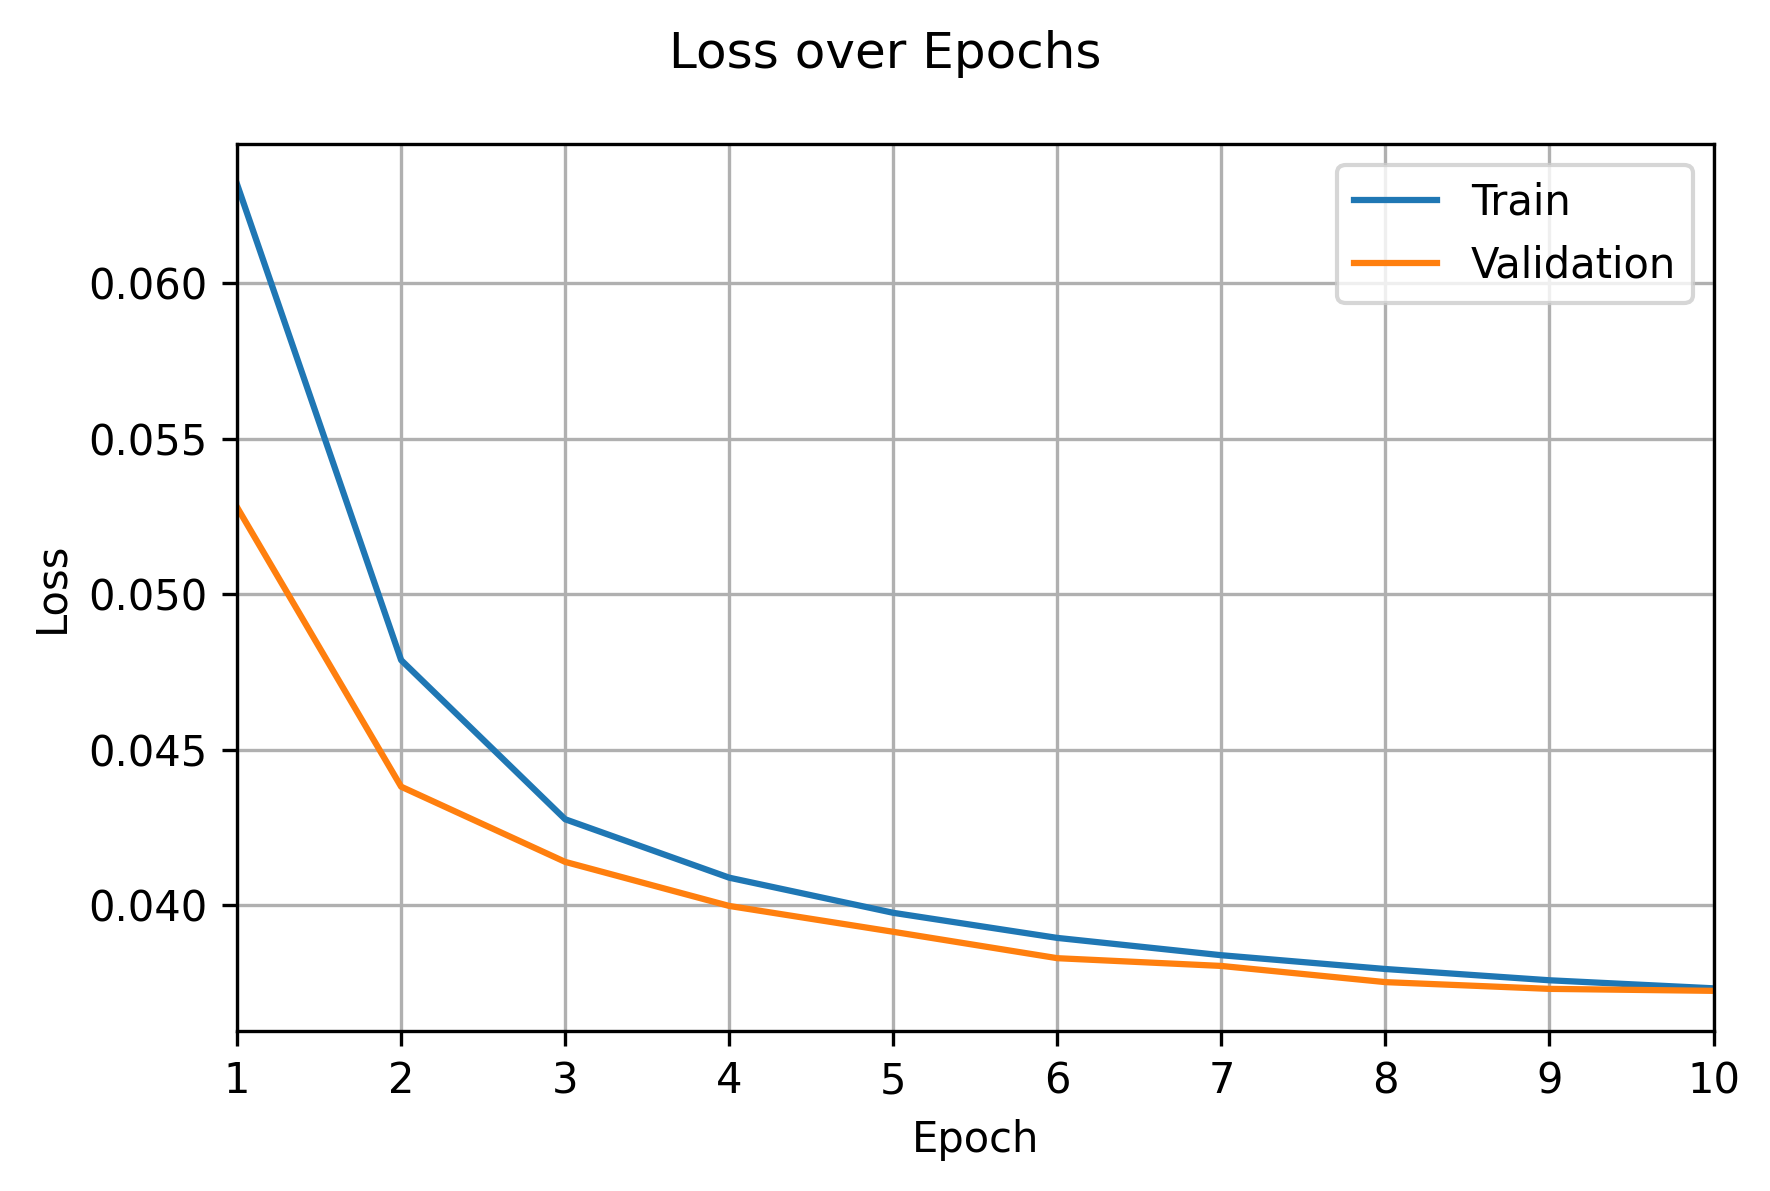

In [31]:
loss_logger.plot()

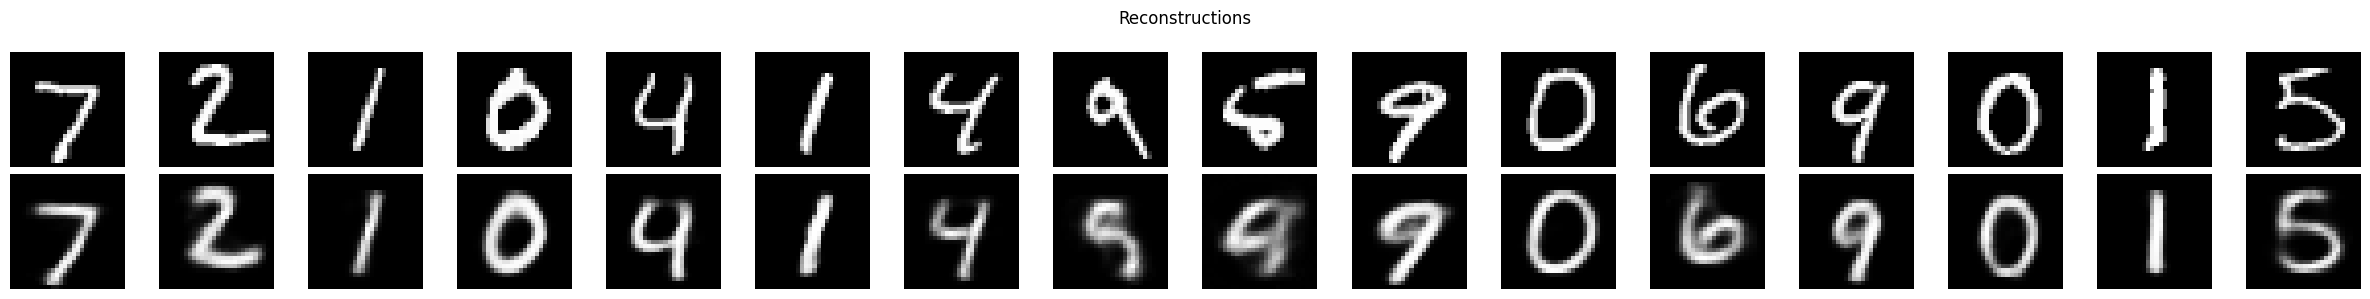

In [32]:
xs, _ = next(iter(test_loader))
pred, __, _ = vae(xs.to(trainer.device))

scorch.utils.plot_images(xs, pred.view(-1, 28, 28), title='Reconstructions')

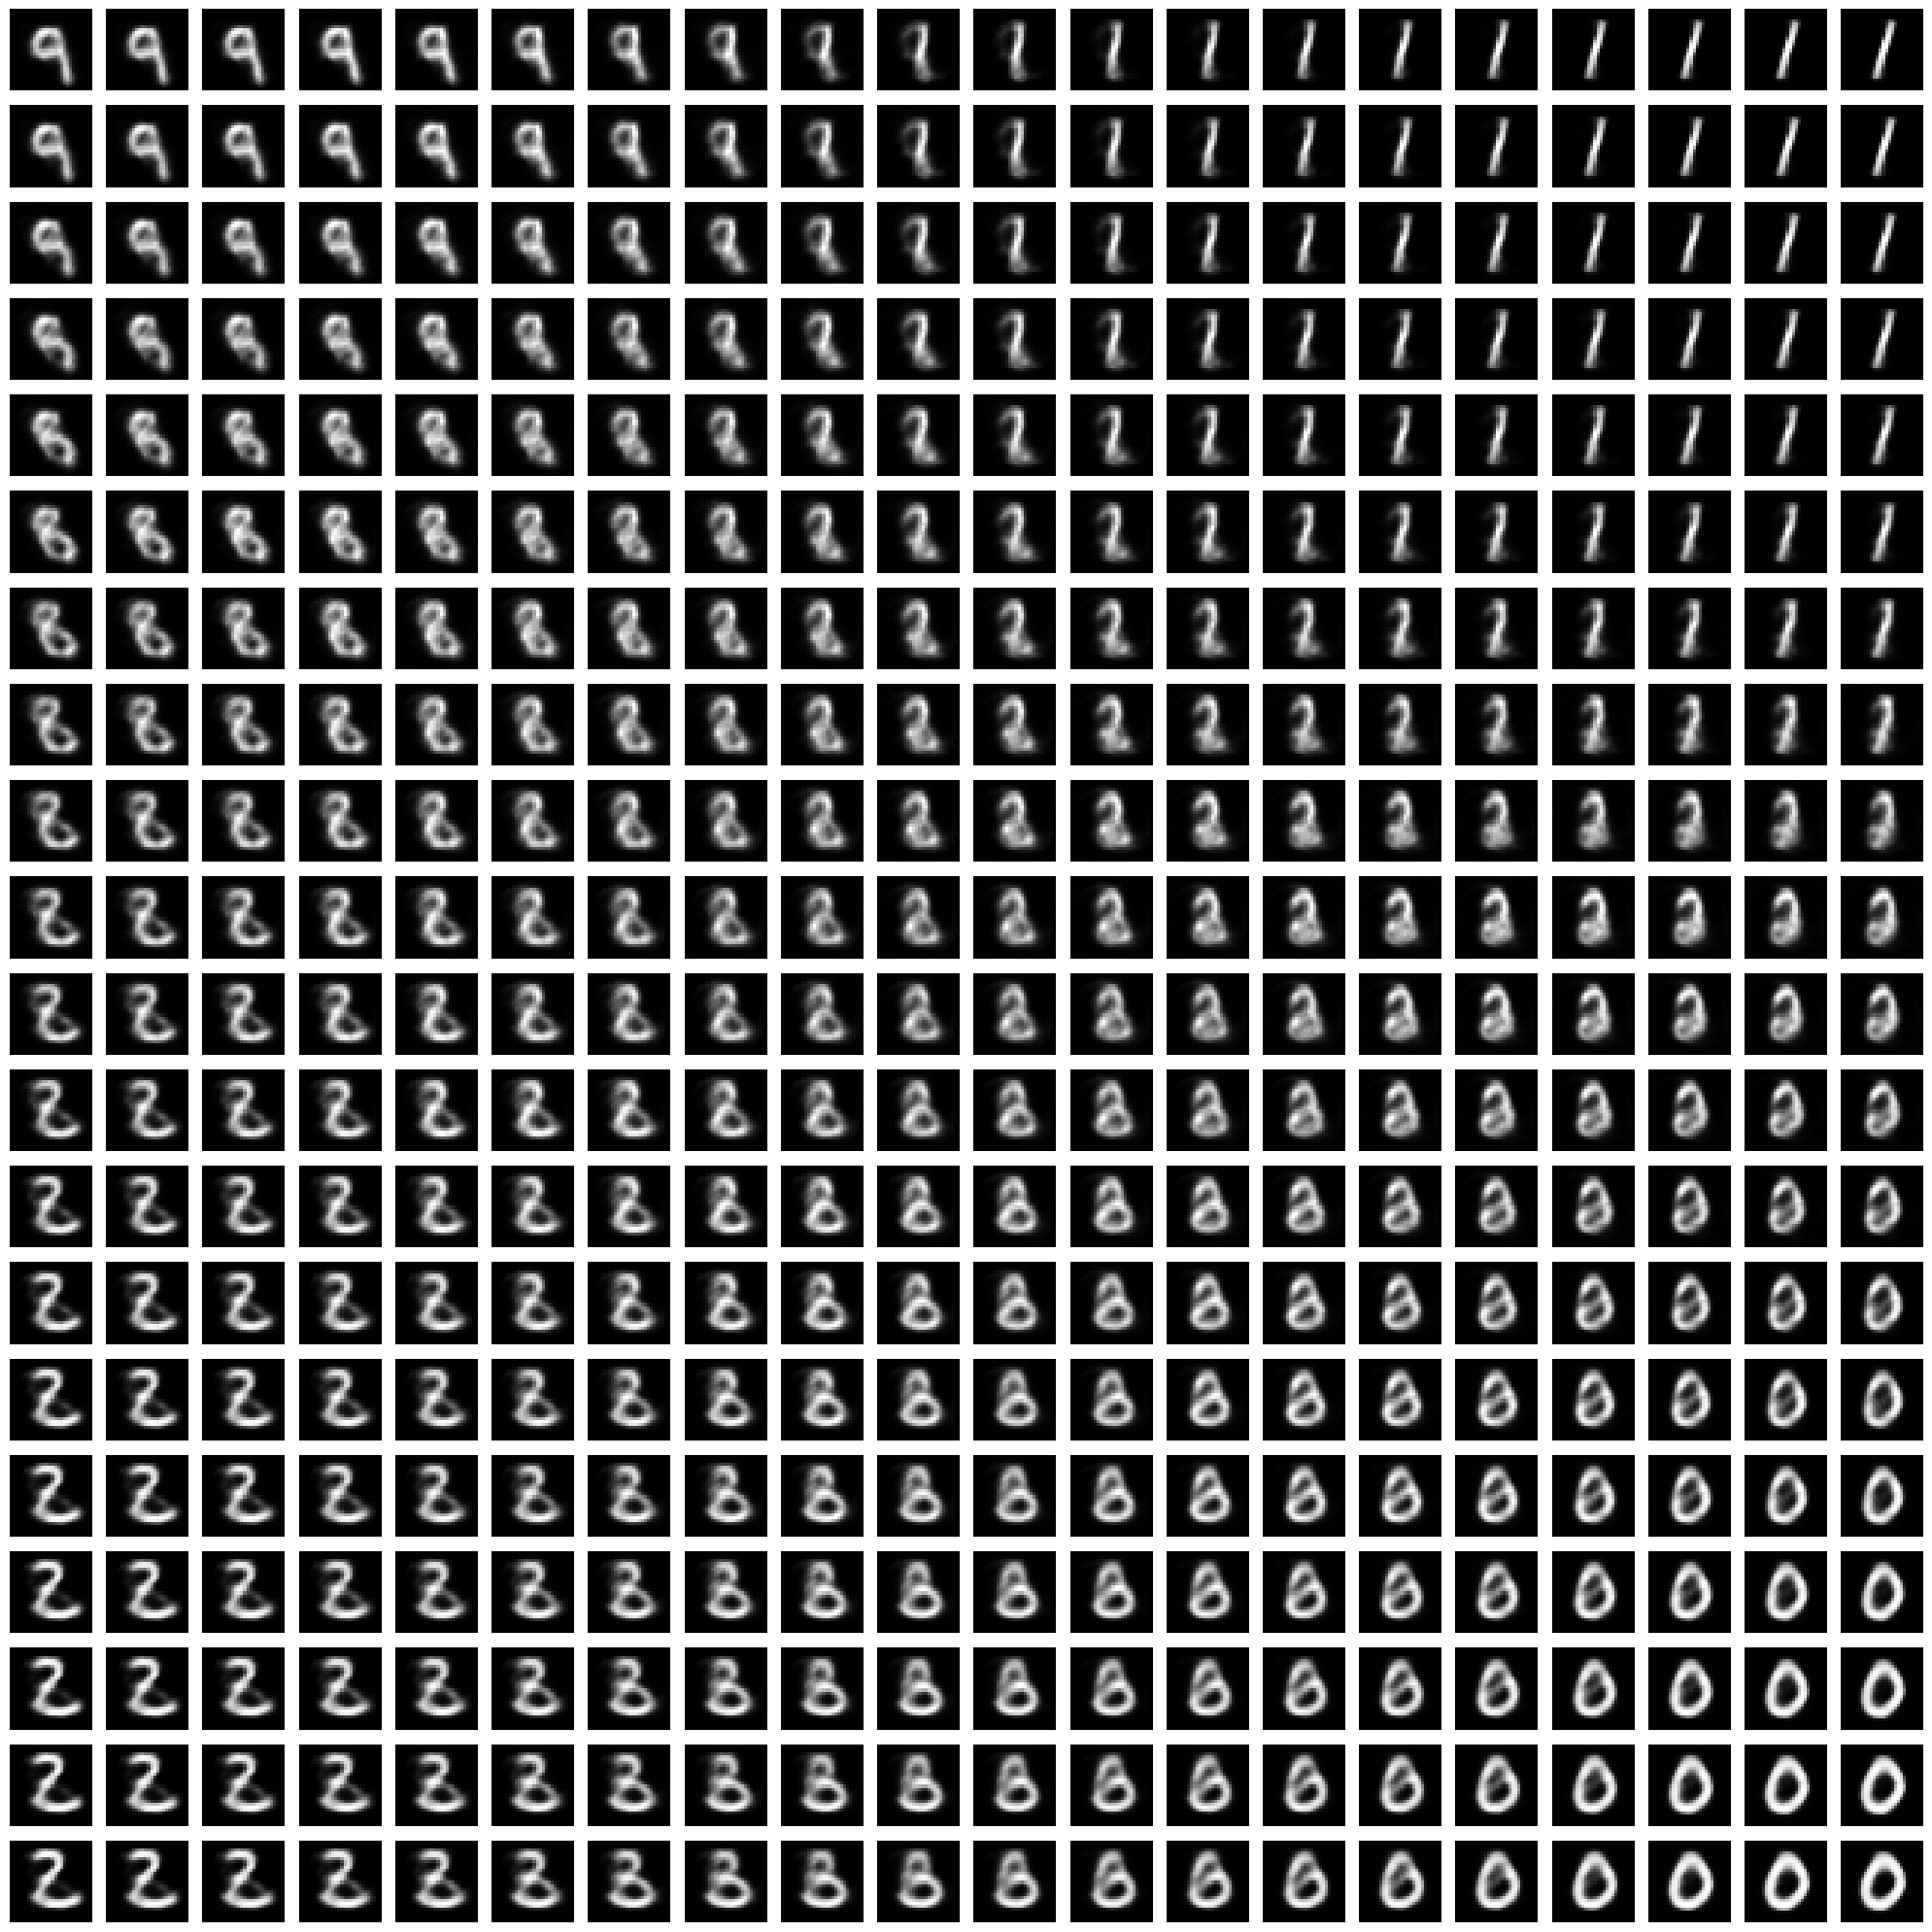

In [33]:
import torch
import matplotlib.pyplot as plt

def bilinear_interpolate(latents, grid_size):
    TL, TR, BL, BR = latents
    grid = []

    for i in torch.linspace(0, 1, grid_size):
        top = TL * (1 - i) + TR * i
        bottom = BL * (1 - i) + BR * i
        row = [top * (1 - j) + bottom * j for j in torch.linspace(0, 1, grid_size)]
        grid.append(torch.stack(row))
    
    return torch.stack(grid).view(-1, TL.shape[-1])

def show_latent_grid(vae, dataloader, grid_size=10):
    vae.eval()

    images, _ = next(iter(dataloader))
    x1, x2, x3, x4 = images[7], images[1], images[2], images[3]

    with torch.no_grad():
        z1, _ = vae.encode(x1.unsqueeze(0).to(trainer.device))  
        z2, _ = vae.encode(x2.unsqueeze(0).to(trainer.device))  
        z3, _ = vae.encode(x3.unsqueeze(0).to(trainer.device))  
        z4, _ = vae.encode(x4.unsqueeze(0).to(trainer.device))  

        interpolated_z = bilinear_interpolate([z1, z2, z3, z4], grid_size)
        decoded = vae.decoder(interpolated_z.to(trainer.device)).cpu()

    fig, axes = plt.subplots(grid_size, grid_size, figsize=(grid_size, grid_size))
    for i in range(grid_size):
        for j in range(grid_size):
            idx = i * grid_size + j
            axes[i, j].imshow(decoded[idx][0].cpu(), cmap='gray')
            axes[i, j].axis('off')
    plt.tight_layout()
    plt.show()

show_latent_grid(vae, test_loader, grid_size=20)

In [34]:
import numpy as np

labeled_test_dataloader = torch.utils.data.DataLoader(test_dataset_base, batch_size=1)

all_labels = []
all_points = np.zeros((len(labeled_test_dataloader), 32), dtype=np.float32)

vae.eval()
with torch.no_grad():
    for i, (image, label) in enumerate(labeled_test_dataloader):
        mu, logvar = vae.encode(image.to(trainer.device))
        all_points[i] = mu[0].detach().cpu()
        all_labels.append(str(int(label[0])))

C:\Users\szewc\AppData\Local\Temp\ipykernel_20168\96124539.py:12: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  all_points[i] = mu[0].detach().cpu()


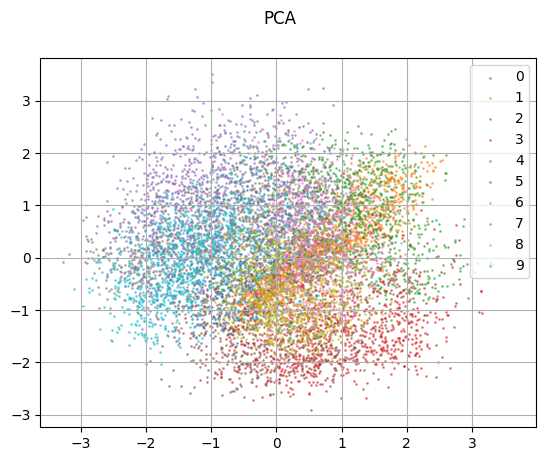

In [35]:
import sklearn

all_points_compressed = sklearn.decomposition.PCA(n_components=2).fit_transform(all_points)

pts_per_digit = {str(i): {'x': [], 'y': []} for i in range(10)}

for pt, l in zip(all_points_compressed, all_labels):
    pts_per_digit[l]['x'].append(pt[0])
    pts_per_digit[l]['y'].append(pt[1])

plt.grid()
for digit, points in pts_per_digit.items():
    plt.scatter(points['x'], points['y'], label=digit, s=1.0, alpha=0.5)
plt.suptitle('PCA')
plt.legend()

In [36]:
all_points_compressed_tsne = sklearn.manifold.TSNE(n_components=2).fit_transform(all_points)


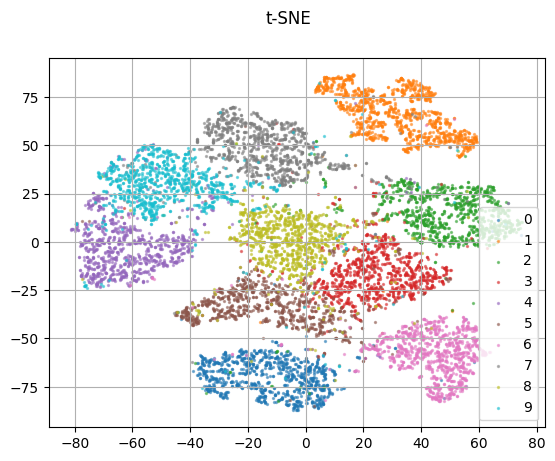

In [37]:
pts_per_digit_tsne = {str(i): {'x': [], 'y': []} for i in range(10)}

for pt, l in zip(all_points_compressed_tsne, all_labels):
    pts_per_digit_tsne[l]['x'].append(pt[0])
    pts_per_digit_tsne[l]['y'].append(pt[1])

plt.grid()
for digit, points in pts_per_digit_tsne.items():
    plt.scatter(points['x'], points['y'], label=digit, s=2.0, alpha=0.5)
plt.suptitle('t-SNE')
plt.legend()